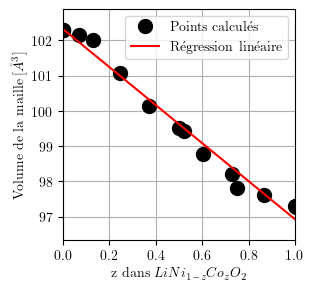

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
import mpltern

_dpi = 100


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=True)
rc('font', family='serif', size = 10)

##############"
# Fig12
##############"

filename = "Fig12.csv"

data = np.loadtxt(filename, skiprows=1,delimiter=',')
z, V = data.T


#Fit linear : 
P = np.poly1d(np.polyfit(z, V, deg=1))

fig = plt.figure(figsize=(3,3))
ax = fig.subplots()
ax.plot(z, V, marker = 'o', ls = 'none', markersize = 10, color = 'black', label = 'Points calculés')
xlim= ax.get_xlim()
ax.plot(xlim, P(xlim), color = 'red', label = "Régression linéaire")

ax.set_xlabel("z dans $LiNi_{1-z}Co_z O_2$")
ax.set_ylabel("Volume de la maille [$\mathring{A}^3$]")

ax.set_xlim(0,1)

ax.grid()
ax.legend()


fig.savefig("Fig12.pgf", dpi = _dpi,bbox_inches='tight')

#Plot single composition LiNi{1-z}Co{z}O2

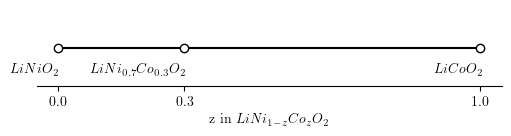

In [2]:
# Choose some nice levels
z = (0,0.3,1)
names = ('$LiNiO_2$', '$LiNi_{0.7}Co_{0.3}O_2$', '$LiCoO_2$')

# Create figure and plot a stem plot with the date
fig, ax = plt.subplots(figsize=(6, 1))#, layout="constrained")

ax.plot(z, np.zeros_like(z), "-o",
        color="k", markerfacecolor="w")  # Baseline and markers on it.

# annotate lines
for d, r in zip(z, names):
    ax.annotate(r, xy=(d, 0),
               xytext=(d,-20), textcoords="offset points",
               horizontalalignment="right",
               verticalalignment="bottom")

# format x-axis with 4-month intervals
#plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_xlim(-0.05,1.05)

# remove y-axis and spines
ax.yaxis.set_visible(False)

for axspine in ["left", "top", "right"] :
    ax.spines[axspine].set_visible(False)

ax.set_xlabel("z in $LiNi_{1-z}Co_{z}O_2$")

ax.set_xticks(z)

#ax.margins(y=0.1)

fig.savefig("Fig14.pgf", dpi = _dpi,bbox_inches='tight')

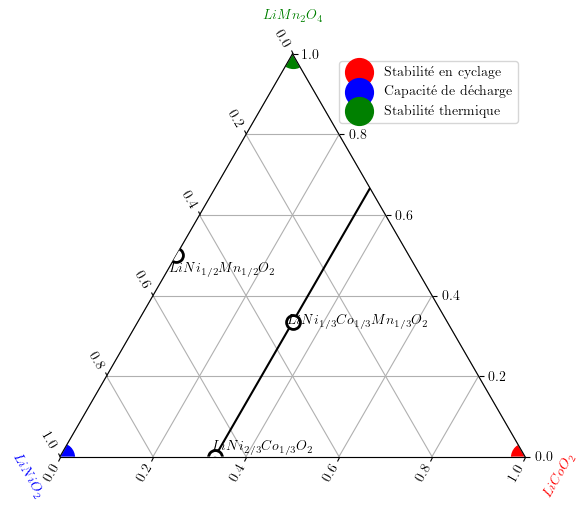

In [114]:
t_comp = [0,1/2,1/3]
l_comp = [2/3,1/2,1/3]
r_comp = [1/3,0,1/3]



fig = plt.figure(figsize = (6,6))
ax = plt.subplot(projection="ternary", ternary_sum=1)

ax.set_tlabel("$LiMn_2O_4$",color='green')
ax.set_llabel("$LiNiO_2$",color = 'blue')
ax.set_rlabel("$LiCoO_2$", color = 'red')

ax.plot([1/3, 1/3], [0, 1], transform=ax.get_raxis_transform(), color = 'black')
ax.scatter(t_comp,l_comp,r_comp, 
           color='white', s=100, edgecolors = "black", linewidth=2,alpha=1,zorder=3)


ax.text(t_comp[0]+0.02, l_comp[0]-0.1, r_comp[0]+0.1, '$LiNi_{2/3}Co_{1/3}O_2$', ha='center', va='center')
ax.text(t_comp[1]+0.05, l_comp[1], r_comp[1]+0.14, '$LiNi_{1/2}Mn_{1/2}O_2$', ha='center', va='center')
ax.text(t_comp[2], l_comp[2]-0.14, r_comp[2]+0.14, '$LiNi_{1/3}Co_{1/3}Mn_{1/3}O_2$', ha='center', va='center')

ax.scatter([0],[0],[1], color = 'red', s = 400, label = "Stabilité en cyclage")
ax.scatter([0],[1],[0], color = 'blue', s = 400, label = "Capacité de décharge")
ax.scatter([1],[0],[0], color = 'green', s = 400, label= "Stabilité thermique")

ax.grid()

ax.legend()

fig.savefig("Fig20.pgf", dpi = _dpi,bbox_inches='tight')
